<a href="https://colab.research.google.com/github/viniciusarnom/estudo_dirigido/blob/main/Importar%20e%20Concatenar%20BES%20Day2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Iniciando a concatenação para o arquivo: WiFi_Day_2_bes_slice_completo.bin
Lendo e adicionando: WiFi_Day_2_bes_s1.bin...
Lendo e adicionando: WiFi_Day_2_bes_s2.bin...
Lendo e adicionando: WiFi_Day_2_bes_s3.bin...
Lendo e adicionando: WiFi_Day_2_bes_s4.bin...
Lendo e adicionando: WiFi_Day_2_bes_s5.bin...
Concatenação concluída com sucesso! Arquivo gerado: WiFi_Day_2_bes_slice_completo.bin

Gerando gráfico com as primeiras 5000 amostras de WiFi_Day_2_bes_slice_completo.bin...


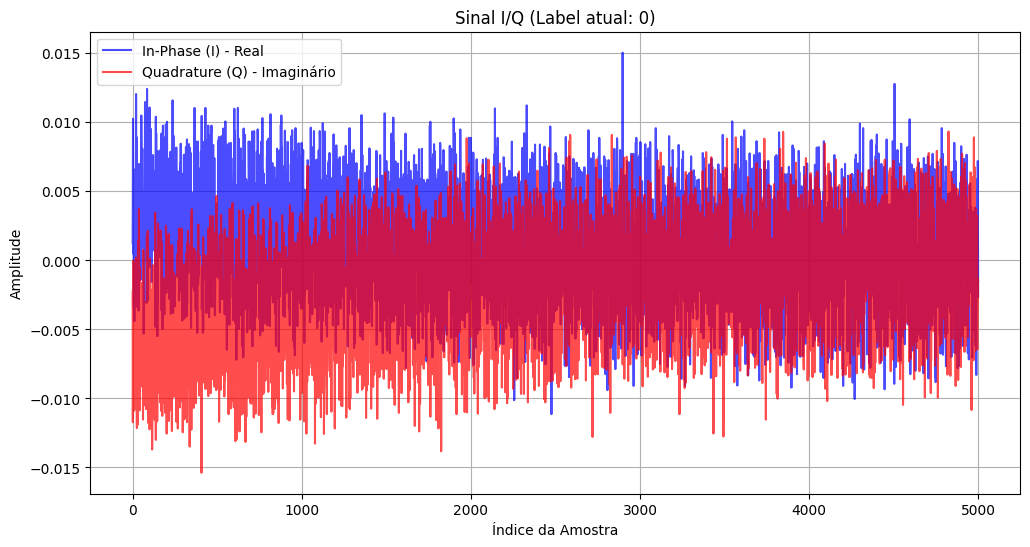

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

def concatenar_arquivos_numpy(arquivos_entrada, arquivo_saida):
    """
    Lê uma lista de arquivos .bin contendo dados complexos (I/Q)
    usando NumPy, adiciona a label e os concatena num único arquivo de saída.
    """
    print(f"Iniciando a concatenação para o arquivo: {arquivo_saida}")

    # Abre o arquivo de saída no modo de escrita binária ('wb')
    with open(arquivo_saida, 'wb') as f_out:
        for nome_arquivo in arquivos_entrada:
            if os.path.exists(nome_arquivo):
                print(f"Lendo e adicionando: {nome_arquivo}...")

                # O formato cf32 (Complex Float 32-bit) é interpretado no NumPy como complex64
                # (32 bits para a parte Real/In-phase e 32 bits para a parte Imaginária/Quadrature)
                data = np.fromfile(nome_arquivo, dtype=np.complex64)

                # --- INÍCIO DA ADIÇÃO DA LABEL ---
                # 1. Separa a parte Real e Imaginária convertendo para float32
                real_part = np.real(data).astype(np.float32)
                imag_part = np.imag(data).astype(np.float32)

                # 2. Cria uma coluna (array) cheia de ZEROS com o exato tamanho dos dados
                # (Como é a base 'bes' novamente, assumimos a label 0.0. Altere se necessário)
                labels = np.full(len(data), 0.0, dtype=np.float32)

                # 3. Empilha tudo em colunas: [Label, Real, Imaginário]
                dados_com_label = np.column_stack((labels, real_part, imag_part))

                # Grava os dados diretamente no arquivo de saída
                dados_com_label.tofile(f_out)
                # --- FIM DA ADIÇÃO DA LABEL ---

            else:
                print(f"Aviso: O arquivo {nome_arquivo} não foi encontrado e será ignorado.")

    print(f"Concatenação concluída com sucesso! Arquivo gerado: {arquivo_saida}\n")

def plotar_amostra(arquivo_bin, num_amostras=10000):
    """
    Lê e plota um pequeno slice (amostra) do arquivo final gerado para validar os dados.
    """
    if os.path.exists(arquivo_bin):
        print(f"Gerando gráfico com as primeiras {num_amostras} amostras de {arquivo_bin}...")

        # Como agora temos [Label, Real, Imag] em float32, precisamos ler (num_amostras * 3)
        data_raw = np.fromfile(arquivo_bin, dtype=np.float32, count=num_amostras * 3)

        # Redimensiona para o formato de colunas para facilitar o plot (N linhas, 3 colunas)
        data_reshaped = data_raw.reshape(-1, 3)

        # Extrai as partes I e Q (ignoramos a coluna 0 no plot porque é apenas a Label)
        real_data = data_reshaped[:, 1]
        imag_data = data_reshaped[:, 2]

        plt.figure(figsize=(12, 6))
        # Plota a parte Real (In-Phase / I)
        plt.plot(real_data, label='In-Phase (I) - Real', color='blue', alpha=0.7)
        # Plota a parte Imaginária (Quadrature / Q)
        plt.plot(imag_data, label='Quadrature (Q) - Imaginário', color='red', alpha=0.7)

        # Mostra a label no título para confirmar
        label_atual = int(data_reshaped[0, 0])
        plt.title(f'Sinal I/Q (Label atual: {label_atual})')
        plt.xlabel('Índice da Amostra')
        plt.ylabel('Amplitude')
        plt.legend()
        plt.grid(True)
        plt.show()
    else:
        print("Arquivo final não encontrado para gerar o gráfico.")

# ==============================================================
# Execução do Script
# ==============================================================

# Lista com os nomes dos arquivos (base Day 2 bes) na ordem correta
arquivos_para_concatenar = [
    "WiFi_Day_2_bes_s1.bin",
    "WiFi_Day_2_bes_s2.bin",
    "WiFi_Day_2_bes_s3.bin",
    "WiFi_Day_2_bes_s4.bin",
    "WiFi_Day_2_bes_s5.bin"
]

# Novo nome do arquivo final que conterá o "slice"
nome_arquivo_saida = "WiFi_Day_2_bes_slice_completo.bin"

# 1. Realiza a concatenação
concatenar_arquivos_numpy(arquivos_para_concatenar, nome_arquivo_saida)

# 2. Plota uma amostra para validar os dados concatenados
plotar_amostra(nome_arquivo_saida, num_amostras=5000)